# Final Project – Machine Learning

# Prediction of Student Academic Performance


Nicolás Carrión

# 1. Introduction

The PISA (*Programme for International Student Assessment*) assessment, developed by the Organisation for Economic Co-operation and Development (OECD), is one of the most important international studies for measuring the academic performance of 15-year-old students in key areas such as mathematics, reading, and science. PISA aims to evaluate the extent to which students have acquired the knowledge and skills necessary to participate fully in modern society, focusing not only on the acquisition of knowledge but also on the ability to apply it in real-world situations [1].

In addition to assessing academic performance, PISA collects a large amount of contextual information related to students' socioeconomic, family, school, and personal factors. This information makes it possible to study the influence of various factors on academic achievement, contributing to the identification of patterns that may be useful for designing strategies and policies aimed at improving educational quality.

However, the large number of variables available in the PISA questionnaires presents an analytical challenge due to high dimensionality, the presence of missing values, and potential redundancy among variables. In this context, machine learning techniques provide tools capable of modeling complex relationships and generating accurate predictions from large volumes of data.

In this project, the PISA 2022 dataset will be used with the objective of predicting students' mathematics performance, represented by the `PV_MATH_MEAN` variable, which corresponds to the average of the ten plausible mathematics values. To achieve this, a feature selection process will first be conducted in order to identify the most relevant variables and reduce the dimensionality of the problem. Subsequently, an Exploratory Data Analysis (EDA) will be performed on the selected variables, and two machine learning models will be trained: a Random Forest Regressor and an Artificial Neural Network.

Finally, the performance of both models will be evaluated using regression metrics and compared through statistical tests to determine whether significant differences exist between their predictive capabilities. This work constitutes an initial approach to the study of academic performance through machine learning techniques and may serve as a foundation for future, more extensive research, including the development of thesis projects focused on interpreting factors associated with student achievement.

## 2. Data Ingestion

First, we extract the data from the ZIP file available at https://webfs.oecd.org/pisa2022/SCH_QQQ_SAS.zip. To improve processing efficiency, the dataset is stored in Parquet format. At the same time, we split the data into training and test sets.

In [1]:
import pandas as pd

def sas_to_parquet():
    df = pd.read_sas(
        "data/CY08MSP_STU_QQQ.SAS7BDAT",
        format="sas7bdat"
    )
    print("Loaded SAS file into DataFrame")

    for col in df.select_dtypes(include=[object]).columns:
        df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

    df.to_parquet("data/pisa2022.parquet", index=False)
    print("Converted SAS file to Parquet format and saved as data/pisa2022.parquet")

In [2]:
sas_to_parquet()

Loaded SAS file into DataFrame
Converted SAS file to Parquet format and saved as data/pisa2022.parquet


In [1]:
import pyarrow.dataset as ds
from sklearn.model_selection import train_test_split

def split_data(test_size=0.2, random_state=42):
    dataset = ds.dataset('data/pisa2022.parquet', format='parquet')
    table = dataset.to_table()
    
    train_table, test_table = train_test_split(
        table.to_pandas(),
        test_size=test_size,
        random_state=random_state
    )

    print(f"Train rows: {len(train_table)} ({(1-test_size)*100:.1f}%)")
    print(f"Test rows: {len(test_table)} ({test_size*100:.1f}%)")

    return train_table, test_table

def save_split(train_df, test_df):
    train_df.to_parquet('data/train.parquet', index=False)
    print("Saved train split to data/train.parquet")

    test_df.to_parquet('data/test.parquet', index=False)
    print("Saved test split to data/test.parquet")

In [2]:
save_split(*split_data())

Train rows: 490995 (80.0%)
Test rows: 122749 (20.0%)
Saved train split to data/train.parquet
Saved test split to data/test.parquet


In [4]:
import pyarrow.parquet as pq

table = pq.read_table("data/pisa2022.parquet")

print("Shape:", table.num_rows, "x", table.num_columns)
print("Estimated memory usage (MB):", table.nbytes / 1024**2)

Shape: 613744 x 1278
Estimated memory usage (MB): 6100.628432273865


Given the size of the dataset, loading all records into memory is not practical. Consequently, the analysis must be conducted either on selected subsets of columns or on a reduced sample of rows (for example, 5% of the data, corresponding to approximately 30k records).

In [5]:
print(f"5% of the data: {table.num_rows * 0.05} rows")

5% of the data: 30687.2 rows


## 3. ETL

Next, we clean the dataset to retain only the features and the target variable, `PV_MATH_MEAN`. Since this variable is not directly available in the original dataset, it must first be computed and added. To reduce redundancy, all other plausible values (including those for mathematics, reading, and science) are removed, keeping only `PV_MATH_MEAN` as the target variable.

## **FALTA ONE-HOT O TRATAR NULOS**

In [10]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa

def extract_data():
    train = pq.read_table('data/train.parquet')
    test = pq.read_table('data/test.parquet')
    return {'train': train, 'test': test}

def transform_data(table):
    columns = table.column_names

    math_cols = [f'PV{i}MATH' for i in range(1, 11)]
    available = [c for c in math_cols if c in columns]

    if available:
        arrays = [table[c] for c in available]
        mean_array = arrays[0]
        for arr in arrays[1:]:
            mean_array = pc.add(mean_array, arr)
        mean_array = pc.divide(mean_array, len(available))
        table = table.append_column("PV_MATH_MEAN",mean_array)
        print(f"Transformed {len(available)} PV_MATH columns into PV_MATH_MEAN.")

    pv_cols = [c for c in columns if c.startswith("PV") and c != "PV_MATH_MEAN"]
    print(f"Dropping {len(pv_cols)} PV columns")
    table = table.drop_columns(pv_cols)

    return table

def load_data(table, file_name):
    pq.write_table(table, file_name)
    print(f"Saved transformed data to {file_name}")

In [11]:
for name, table in extract_data().items():
    table = transform_data(table)
    load_data(table, file_name=f"data/{name}_transformed.parquet")

Transformed 10 PV_MATH columns into PV_MATH_MEAN.
Dropping 110 PV columns
Saved transformed data to data/train_transformed.parquet
Transformed 10 PV_MATH columns into PV_MATH_MEAN.
Dropping 110 PV columns
Saved transformed data to data/test_transformed.parquet


We also need to detect which features are categorical to transform them with one-hot encoding

In [2]:
import pandas as pd

def detect_unique_values():
    df = pd.read_parquet('data/train_transformed.parquet')
    unique_counts = df.nunique()
    return unique_counts

unique_counts = detect_unique_values()

In [10]:
# char columns

char_columns = pd.read_parquet('data/train_transformed.parquet').select_dtypes(include=['object']).columns

print(f"Character columns: {list(char_columns)}")

Character columns: ['CNT', 'CYC', 'NatCen', 'STRATUM', 'SUBNATIO', 'ST250D06JA', 'ST250D07JA', 'ST251D08JA', 'ST251D09JA', 'ST330D10WA', 'OCOD1', 'OCOD2', 'OCOD3', 'PROGN', 'COBN_S', 'COBN_M', 'COBN_F', 'VER_DAT']


In [11]:
char_columns.shape

(18,)

In [8]:
# sort
unique_counts = unique_counts.sort_values(ascending=False)
max_col_length = max(len(col) for col in unique_counts.index)
print(f"{'Column':<{max_col_length}}  Unique Values")
for col, count in unique_counts.items():
    print(f"{col+':':<{max_col_length+1}} {count}")

Column        Unique Values
CNTSTUID:     490995
PV_MATH_MEAN: 473288
HOMEPOS:      58131
W_FSTURWT44:  57053
W_FSTURWT64:  57025
W_FSTURWT24:  57023
W_FSTURWT65:  57015
W_FSTURWT5:   57014
W_FSTURWT73:  57007
W_FSTURWT39:  57007
W_FSTURWT34:  57005
W_FSTURWT46:  57005
W_FSTURWT4:   57005
W_FSTURWT33:  57001
W_FSTURWT12:  56996
W_FSTURWT56:  56992
W_FSTURWT67:  56992
W_FSTURWT32:  56990
W_FSTURWT11:  56990
W_FSTURWT69:  56990
W_FSTURWT72:  56989
W_FSTURWT63:  56988
W_FSTURWT76:  56988
W_FSTURWT26:  56987
W_FSTURWT48:  56986
W_FSTURWT6:   56985
W_FSTURWT62:  56984
W_FSTURWT61:  56981
W_FSTURWT16:  56978
W_FSTURWT47:  56978
W_FSTURWT17:  56976
W_FSTURWT77:  56975
W_FSTURWT80:  56975
W_FSTURWT54:  56974
W_FSTURWT55:  56974
W_FSTURWT21:  56972
W_FSTURWT29:  56972
W_FSTURWT38:  56970
W_FSTURWT9:   56970
W_FSTURWT49:  56970
W_FSTURWT15:  56968
W_FSTURWT35:  56965
W_FSTURWT2:   56962
W_FSTURWT50:  56961
W_FSTURWT7:   56960
W_FSTURWT40:  56958
W_FSTURWT28:  56957
W_FSTURWT52:  56957
W_FSTURWT4

## 4. Feature Selection

Since the dataset has more than 1.2k columns, we need to choose the ones more relevant for predicting the desired output. First we must process the features that are categorical by selecting which to apply one-hot encoding or frequency encoding depending on the amount of categories or the context the feature gives.

We can obtain the codebook of the dataset from https://webfs.oecd.org/pisa2022/CY08MSP_CODEBOOK_27thJune24.xlsx, where we can obtain a description of each column and the possible categories it contains. With this information, I constructed a CSV file containing each variable along with a count of the number of rows in which it appears. Since each additional entry indicates a possible category of the variable, any variable with a count greater than 1 can be considered categorical.

In [5]:
import pandas as pd

var_counts = pd.read_csv('dataset_var_counts.csv', sep=';')
df_cols = pd.read_parquet('data/train_transformed.parquet').columns

# drop columns that are not in the dataframe
var_counts = var_counts[var_counts['VAR'].isin(df_cols)]

print(var_counts.shape)
display(var_counts)

(1168, 2)


,VAR,COUNT
0,CNTSCHID,1
1,CNTSTUID,1
2,CYC,1
3,AGE,1
4,W_FSTUWT,1
...,...,...
1273,OCOD1,625
1274,OCOD2,625
1275,OCOD3,625
1276,PROGN,664


In [8]:
numerical_columns = var_counts[var_counts['COUNT'] == 1]['VAR'].tolist()
len(numerical_columns)

88

In [9]:
categorical_columns = var_counts[var_counts['COUNT'] > 1]['VAR'].tolist()
var_counts[var_counts['COUNT'] > 1]

,VAR,COUNT
198,OECD,3
199,ADMINMODE,3
200,Option_CT,3
201,Option_FL,3
202,Option_ICTQ,3
...,...,...
1273,OCOD1,625
1274,OCOD2,625
1275,OCOD3,625
1276,PROGN,664


Although we have the count of categories each column has (obtained form codebook), we should verify it on the training dataset.

In [68]:
import pandas as pd
import pyarrow.parquet as pq
from collections import defaultdict

var_counts = pd.read_csv('dataset_var_counts.csv', sep=';')

parquet_file = pq.ParquetFile('data/train_transformed.parquet')

df_cols = parquet_file.schema.names

var_counts = var_counts[var_counts['VAR'].isin(df_cols)].copy()

numerical_columns = var_counts[var_counts['COUNT'] == 1]['VAR'].tolist()
categorical_columns = var_counts[var_counts['COUNT'] > 1]['VAR'].tolist()

schema = parquet_file.schema_arrow

char_columns = [
    field.name
    for field in schema
    if str(field.type) in ["string", "large_string"]
]

unique_sets = defaultdict(set)

batch_size = 100_000

for batch in parquet_file.iter_batches(batch_size=batch_size):
    df_batch = batch.to_pandas(split_blocks=True, self_destruct=True)

    for col in df_batch.columns:
        # evitar overhead de NaN
        values = df_batch[col].dropna().unique()
        if len(values) > 0:
            unique_sets[col].update(values)

unique_counts = pd.Series({
    col: len(vals) for col, vals in unique_sets.items()
})

final_df = pd.DataFrame({
    'variable': var_counts['VAR'].values,
    'count_csv': var_counts['COUNT'].values
})

final_df['unique_count_parquet'] = final_df['variable'].map(unique_counts)

final_df['is_categorical_csv'] = final_df['variable'].isin(categorical_columns)
final_df['is_numerical_csv'] = final_df['variable'].isin(numerical_columns)

final_df['is_char'] = final_df['variable'].isin(char_columns)
final_df['is_numeric_dtype'] = ~final_df['is_char']

def infer_type(row):
    if row['is_char']:
        return 'char'
    elif row['is_categorical_csv']:
        return 'categorical'
    else:
        return 'numerical'

final_df['final_type'] = final_df.apply(infer_type, axis=1)

final_df

,variable,count_csv,unique_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
0,CNTSCHID,1,21567,False,True,False,True,numerical
1,CNTSTUID,1,490995,False,True,False,True,numerical
2,CYC,1,1,False,True,True,False,char
3,AGE,1,16,False,True,False,True,numerical
4,W_FSTUWT,1,45875,False,True,False,True,numerical
...,...,...,...,...,...,...,...,...
1163,OCOD1,625,624,True,False,True,False,char
1164,OCOD2,625,624,True,False,True,False,char
1165,OCOD3,625,607,True,False,True,False,char
1166,PROGN,664,438,True,False,True,False,char


With this table, we can infer the columns that don't give any usefull information (only 1 unique value in all the dataset) and drop them from the dataset, the categorical columns that are of type char or have a count on the csv greater than 1, and the numerical columns. In case that a categorical column that isn't of type char, but has a unique_count on the parquet file greater than the count on the csv file, then it suggests that it might be a numerical variable instead but with different categories of null values.

In [71]:
# Columns to drop for having only one unique value in the parquet file (meaning they are constant)
columns_to_drop = set()
mask1 = final_df['unique_count_parquet'] == 1

display(final_df[mask1])

columns_to_drop.update(final_df[mask1]['variable'].tolist())
print(f"Columns to drop (unique_count_parquet == 1): {columns_to_drop}")

# Columns that are character type meaning that should be treated as categorical
char_columns = set()
mask2 = (final_df['final_type'] == 'char') & (~mask1)

display(final_df[mask2])

char_columns.update(final_df[mask2]['variable'].tolist())
print(f"Character columns: {char_columns}")

# Columns that are categorical but have more unique values in the parquet file than in the csv file, meaning that they should be treated as numerical instead of categorical
cat_exceptions = set()
mask3 = (final_df['final_type'] == 'categorical') & (~mask1) & (~mask2) & (final_df['unique_count_parquet'] > final_df['count_csv'])

display(final_df[mask3])

cat_exceptions.update(final_df[mask3]['variable'].tolist())
print(f"Categorical exceptions: {cat_exceptions}")

# Columns that are categorical without exceptions, meaning that they should be treated as categorical
categorical_columns = set()
mask4 = (final_df['final_type'] == 'categorical') & (~mask1) & (~mask2) & (~mask3)

display(final_df[mask4])

categorical_columns.update(final_df[mask4]['variable'].tolist())
print(f"Categorical columns: {categorical_columns}")

,variable,count_csv,unique_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
2,CYC,1,1,False,True,True,False,char


Columns to drop (unique_count_parquet == 1): {'CYC'}


,variable,count_csv,unique_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
87,VER_DAT,1,281,False,True,True,False,char
1148,CNT,82,80,True,False,True,False,char
1150,NatCen,85,84,True,False,True,False,char
1151,SUBNATIO,93,88,True,False,True,False,char
1153,ST250D07JA,110,106,True,False,True,False,char
1154,ST250D06JA,130,126,True,False,True,False,char
1155,ST330D10WA,145,143,True,False,True,False,char
1157,ST251D09JA,172,166,True,False,True,False,char
1158,ST251D08JA,220,214,True,False,True,False,char
1159,COBN_S,253,245,True,False,True,False,char


Character columns: {'SUBNATIO', 'OCOD2', 'PROGN', 'ST250D06JA', 'ST251D08JA', 'COBN_M', 'ST250D07JA', 'STRATUM', 'OCOD1', 'COBN_S', 'CNT', 'ST330D10WA', 'VER_DAT', 'COBN_F', 'NatCen', 'OCOD3', 'ST251D09JA'}


,variable,count_csv,unique_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
98,ST326Q07JA,6,30,True,False,False,True,categorical
99,ST326Q08JA,6,27,True,False,False,True,categorical
100,ST326Q09JA,6,29,True,False,False,True,categorical
101,ST326Q10JA,6,28,True,False,False,True,categorical
102,ST326Q11JA,6,28,True,False,False,True,categorical
...,...,...,...,...,...,...,...,...
194,ATTIMMP,6,1045,True,False,False,True,categorical
195,CREATHME,6,13238,True,False,False,True,categorical
196,CREATACT,6,10214,True,False,False,True,categorical
197,CREATOPN,6,13775,True,False,False,True,categorical


Categorical exceptions: {'ST326Q11JA', 'LIFESAT', 'BODYIMA', 'WB152Q01HA', 'BELONG', 'ICTREG', 'PQMCAR', 'COGACRCO', 'PARINVOL', 'EMPATAGR', 'FEELLAH', 'FLSCHOOL', 'FLFAMILY', 'PQSCHOOL', 'FLMULTSB', 'CREATOR', 'ST059Q02JA', 'ST059Q01TA', 'OPENART', 'CREATAS', 'MATHEF21', 'ICTQUAL', 'GRADE', 'HOMEPOS', 'ICTWKEND', 'ICTFEED', 'PROBSELF', 'ICTDISTR', 'ACCESSFA', 'CREATACT', 'ICTRES', 'MATHPERS', 'ASSERAGR', 'SOCCON', 'BSMJ', 'BULLIED', 'LEARRES', 'ICTSUBJ', 'ST326Q09JA', 'EMOCOAGR', 'FAMSUP', 'COOPAGR', 'CREATOPN', 'CURSUPP', 'SCHRISK', 'IMAGINE', 'FRINFLFM', 'CREATFAM', 'BMMJ1', 'EXPOFA', 'FAMSUPSL', 'PSYCHSYM', 'ST326Q12JA', 'CREATHME', 'ACCESSFP', 'ICTEFFIC', 'INFOSEEK', 'ANXMAT', 'SCHSUST', 'ICTINFO', 'ST016Q01NA', 'WB151Q01HA', 'STRESAGR', 'EXPWB', 'ICTWKDY', 'CREATOOS', 'FLCONICT', 'FEELSAFE', 'PQMIMP', 'FAMCON', 'CURIOAGR', 'ICTENQ', 'EXPO21ST', 'ICTHOME', 'CREATOP', 'CREATSCH', 'ATTIMMP', 'BFMJ2', 'ST326Q08JA', 'TEACHSUP', 'DISCLIM', 'PASCHPOL', 'FLCONFIN', 'ST326Q07JA', 'ICTSCH'

,variable,count_csv,unique_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
88,OECD,3,2,True,False,False,True,categorical
89,ADMINMODE,3,2,True,False,False,True,categorical
90,Option_CT,3,2,True,False,False,True,categorical
91,Option_FL,3,2,True,False,False,True,categorical
92,Option_ICTQ,3,2,True,False,False,True,categorical
...,...,...,...,...,...,...,...,...
1147,LANGTEST_PAQ,73,16,True,False,False,True,categorical
1149,CNTRYID,82,80,True,False,False,True,categorical
1152,BOOKID,106,97,True,False,False,True,categorical
1156,REGION,146,138,True,False,False,True,categorical


Categorical columns: {'ST348Q02JA', 'PA177Q03HA', 'ST330Q01WA', 'ST268Q07JA', 'ST275Q08WA', 'WB154Q05HA', 'ST283Q09JA', 'ST127Q02TA', 'FL166Q02HA', 'ST324Q10JA', 'ST309Q01JA', 'ST322Q01JA', 'ST261Q10JA', 'PA196Q03WA', 'IC180Q03JA', 'ST313Q10JA', 'ST283Q06JA', 'ST338Q08JA', 'ST347Q02JA', 'WB171Q04HA', 'FL167Q06JA', 'ST295Q02JA', 'ST273Q04JA', 'ST256Q03JA', 'ST309Q05JA', 'ST331Q03JA', 'ST034Q01TA', 'ST125Q01NA', 'ST285Q03JA', 'ST315Q01JA', 'ST343Q04JA', 'FL159Q04HA', 'ST307Q06JA', 'ST313Q01JA', 'ST291Q10JA', 'ST303Q05JA', 'WB162Q01HA', 'ST338Q04JA', 'IC177Q01JA', 'FL172Q05JA', 'ST351Q01JA', 'WB168Q03HA', 'ST005Q01JA', 'ST301Q05JA', 'ST309Q09JA', 'PA008Q10NA', 'ST296Q01JA', 'WB155Q01HA', 'ST289Q01WA', 'ST326Q05JA', 'ST335Q03JA', 'PA175Q02HA', 'PA167Q04HA', 'ST038Q08NA', 'ST324Q13JA', 'FL169Q07JA', 'IC179Q02JA', 'IC172Q06JA', 'ST313Q06JA', 'ST354Q06JA', 'ST343Q07JA', 'Option_PQ', 'ST351Q05JA', 'ST324Q12JA', 'EFFORT1', 'ST276Q10JA', 'WB172Q01HA', 'FL166Q01HA', 'PAREDINT', 'WB171Q02HA', 'ST3

In [78]:
# drop columns that are constant

features_df = final_df.copy()

features_df = features_df[~features_df['variable'].isin(columns_to_drop)]

# change final_type for categorical exceptions to numerical

features_df.loc[features_df['variable'].isin(cat_exceptions), 'final_type'] = 'numerical'

# change final_type for categorical and char columns to categorical
features_df.loc[features_df['variable'].isin(categorical_columns), 'final_type'] = 'categorical'
features_df.loc[features_df['variable'].isin(char_columns), 'final_type'] = 'categorical'

features_df

,variable,count_csv,unique_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
0,CNTSCHID,1,21567,False,True,False,True,numerical
1,CNTSTUID,1,490995,False,True,False,True,numerical
3,AGE,1,16,False,True,False,True,numerical
4,W_FSTUWT,1,45875,False,True,False,True,numerical
5,W_FSTURWT1,1,56884,False,True,False,True,numerical
...,...,...,...,...,...,...,...,...
1163,OCOD1,625,624,True,False,True,False,categorical
1164,OCOD2,625,624,True,False,True,False,categorical
1165,OCOD3,625,607,True,False,True,False,categorical
1166,PROGN,664,438,True,False,True,False,categorical


Now, for managing categorical columns, we need to choose which of them to transform with one-hot encoding and which with frequency encodign. In this case we select the ones with less than 20 categories to apply one-hot encoding.

In [79]:
features_df['encoding'] = features_df['final_type']

features_df.loc[(features_df['final_type'] == 'categorical') & (features_df['unique_count_parquet'] < 20), 'encoding'] = 'one-hot'
features_df.loc[(features_df['final_type'] == 'categorical') & (features_df['unique_count_parquet'] >= 20), 'encoding'] = 'frequency'

features_df.drop(columns=['count_csv', 'unique_count_parquet', 'is_categorical_csv', 'is_numerical_csv', 'is_char', 'is_numeric_dtype', 'final_type'], inplace=True)
features_df.to_csv('features_encoding.csv', index=False)
features_df

,variable,encoding
0,CNTSCHID,numerical
1,CNTSTUID,numerical
3,AGE,numerical
4,W_FSTUWT,numerical
5,W_FSTURWT1,numerical
...,...,...
1163,OCOD1,frequency
1164,OCOD2,frequency
1165,OCOD3,frequency
1166,PROGN,frequency


In [ ]:
# apply the transformations to the train and test datasets

pendiente organizar el código, ahora sí aplicar transformaciones, luego hacer feature selection (verificar si requiere normalización antes) y con eso ya entrenar modelos de ML (pipeline).

In [ ]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import numpy as np

# Load the transformed training data
df_train = pd.read_parquet('data/train_transformed.parquet')

# Separate features and target
target = 'PV_MATH_MEAN'
X = df_train.drop(columns=[target])
y = df_train[target]

# Remove rows with missing target values
mask = y.notna()
X = X[mask]
y = y[mask]

# Calculate mutual information scores
mi_scores = mutual_info_regression(X.fillna(X.median()), y, random_state=42)

# Create a dataframe with feature scores
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("Top 30 features by mutual information:")
print(feature_scores.head(30))

# Select top features (e.g., top 50)
top_features = feature_scores.head(50)['feature'].tolist()
print(f"\nSelected {len(top_features)} features for modeling")

# Save the selected features
selected_features_df = df_train[top_features + [target]].dropna()
selected_features_df.to_parquet('data/train_selected_features.parquet', index=False)
print(f"Saved {len(selected_features_df)} rows with selected features to data/train_selected_features.parquet")

## 5.

In [1]:
import duckdb

df_sample = duckdb.sql("""
    SELECT *
    FROM 'data/pisa2022.parquet'
    USING SAMPLE reservoir(30000 ROWS) REPEATABLE(42)
""").df()

display(df_sample.head())
print(f"Memory usage (MB): {df_sample.memory_usage(deep=True).sum() / 1024**2}")
print(f"DataFrame shape: {df_sample.shape}")

,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,REGION,OECD,...,PV3MPRE,PV4MPRE,PV5MPRE,PV6MPRE,PV7MPRE,PV8MPRE,PV9MPRE,PV10MPRE,SENWT,VER_DAT
0,MEX,484.0,48400165.0,48406832.0,08MS,048400,MEX07,4840000,48400.0,1.0,...,352.888,337.995,375.873,359.418,401.960,410.025,418.847,416.432,0.52369,01MAY23:16:14:37
1,HKG,344.0,34400130.0,34402744.0,08MS,034400,HKG02,3440000,34400.0,0.0,...,596.099,530.499,541.255,604.273,532.585,554.661,513.895,507.730,0.62452,02MAY23:17:39:52
2,COL,170.0,17000166.0,17004588.0,08MS,017000,COL06,1700000,17000.0,1.0,...,318.039,401.103,397.179,303.572,338.015,397.196,346.018,331.968,0.20303,02MAY23:17:01:32
3,ISR,376.0,37600029.0,37601507.0,08MS,037600,ISR97,3760000,37600.0,1.0,...,275.242,228.303,354.509,271.051,372.317,337.463,325.695,276.540,0.91481,02MAY23:14:24:02
4,ALB,8.0,800050.0,803012.0,08MS,000800,ALB03,0080000,800.0,0.0,...,388.624,395.402,506.401,384.230,415.777,435.493,422.383,483.711,1.07326,03MAY23:10:11:26


Memory usage (MB): 320.9886522293091
DataFrame shape: (30000, 1278)


In [2]:
# select PV1MATH..PV10MATH columns safely and compute their mean
math_cols = [f'PV{i}MATH' for i in range(1, 11)]
available = [c for c in math_cols if c in df_sample.columns]

df_math = df_sample[available]
display(df_math.head())

# add mean of plausible values to the sample
if available:
    df_sample['PV_MATH_MEAN'] = df_math.mean(axis=1)
    display(df_sample[['PV_MATH_MEAN']].head())
else:
    print("No PV*MATH columns found in df_sample.")

,PV1MATH,PV2MATH,PV3MATH,PV4MATH,PV5MATH,PV6MATH,PV7MATH,PV8MATH,PV9MATH,PV10MATH
0,407.686,400.384,377.956,449.481,448.667,392.994,420.495,431.385,374.913,409.772
1,550.164,511.343,546.147,547.082,584.295,546.008,567.235,595.248,579.907,531.397
2,385.452,353.900,361.573,345.688,348.138,334.097,389.110,385.823,317.498,326.034
3,312.059,355.687,327.955,342.485,295.683,306.052,245.930,205.762,257.571,226.893
4,454.664,470.263,445.050,423.344,454.169,429.090,429.840,470.916,484.278,392.237


,PV_MATH_MEAN
0,411.3733
1,555.8826
2,354.7313
3,287.6077
4,445.3851


In [25]:
import pandas as pd
col = 'ST326Q01JA'
df_col = pd.read_parquet("data/pisa2022.parquet", columns=[col])
print(df_col.shape)
print(df_col[col].value_counts(sort=False).sort_index())

(613744, 1)
ST326Q01JA
1.0     77674
2.0    161867
3.0    113479
4.0     57681
5.0     35829
6.0     26434
7.0     23277
8.0     17783
9.0     21504
Name: count, dtype: int64


In [29]:
# dictionary to store unique values and their counts
unique_values = {} 
temp_pd = pd.read_sas("data/CY08MSP_STU_QQQ.SAS7BDAT", format="sas7bdat", encoding="utf-8", chunksize=100000)
for chunk in temp_pd:
    for value in chunk[col].dropna():
        unique_values[value] = unique_values.get(value, 0) + 1
    if len(unique_values) > 100:  # Stop after collecting more than 100 unique values
        break
print(f"Unique values and their counts for column {col}:")
for value, count in unique_values.items():
    print(f"{value}: {count}")

Unique values and their counts for column ST326Q01JA:
3.0: 113479
9.0: 21504
5.0: 35829
4.0: 57681
1.0: 77674
2.0: 161867
6.0: 26434
8.0: 17783
7.0: 23277


In [30]:
count = 0
for val in unique_values.values():
    count += val
print(f"Total count of non-missing values: {count}")
    

Total count of non-missing values: 535528


In [32]:
missing_ratio = df_sample.isnull().mean()
missing_ratio = missing_ratio.sort_values(ascending=False)

print("Missing value ratio for each column:")
print(missing_ratio[missing_ratio > 0.5])

Missing value ratio for each column:
ST326Q10JA    0.975567
ST326Q11JA    0.974633
ST326Q08JA    0.974133
ST326Q12JA    0.973900
ST326Q09JA    0.973767
                ...   
ST285Q02JA    0.508300
IC183Q14JA    0.501300
IC183Q13JA    0.501033
IC183Q15JA    0.500367
IC183Q16JA    0.500167
Length: 644, dtype: float64


In [10]:
df_sample["ST326Q01JA"].value_counts()

ST326Q01JA
2.0    7750
3.0    5573
1.0    3797
4.0    2867
5.0    1745
6.0    1301
7.0    1166
9.0    1065
8.0     848
Name: count, dtype: int64

In [11]:
df_sample["ST326Q07JA"].value_counts()

ST326Q07JA
1.0     202
0.0     150
2.0     148
4.0      62
5.0      61
3.0      56
6.0      37
8.0      32
7.0      22
10.0     12
12.0      5
9.0       3
13.0      3
11.0      2
14.0      1
21.0      1
16.0      1
17.0      1
Name: count, dtype: int64

In [3]:
# drop all pv columns from the sample except for the mean column
pv_columns = [col for col in df_sample.columns if col.startswith('PV')]
pv_columns.remove('PV_MATH_MEAN')  # Keep the mean column
df_sample.drop(columns=pv_columns, inplace=True)
print(df_sample.shape)

(30000, 1169)


In [5]:
df_sample["ST267Q01JA"].value_counts()

ST267Q01JA
3.0    10106
4.0     4544
2.0     1623
1.0      856
Name: count, dtype: int64

,rows,share
CNT,,
ALB,326,0.0109
ARE,1213,0.0404
ARG,579,0.0193
AUS,670,0.0223
AUT,290,0.0097
...,...,...
TUR,374,0.0125
URY,337,0.0112
USA,215,0.0072


Countries: 80
Min rows: 161
Max rows: 1526
Max/Min ratio: 9.48


Text(0, 0.5, 'Rows')

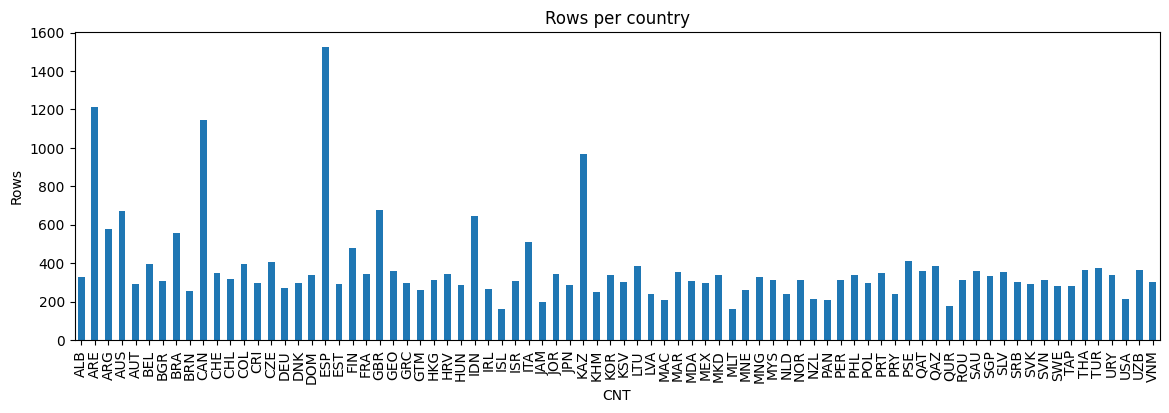

In [28]:
# Balanced Data?

balance = df_sample["CNT"].value_counts().sort_index()

display(
    pd.DataFrame({
        "rows": balance,
        "share": (balance / balance.sum()).round(4)
    })
)

print("Countries:", balance.size)
print("Min rows:", balance.min())
print("Max rows:", balance.max())
print("Max/Min ratio:", round(balance.max() / balance.min(), 2))

ax = balance.plot(kind="bar", figsize=(14, 4), title="Rows per country")
ax.set_xlabel("CNT")
ax.set_ylabel("Rows")

# Referencias

[1] Organisation for Economic Co-operation and Development (OECD), *"Student Performance (PISA),"* OECD. [Online]. Available: https://www.oecd.org/en/topics/student-performance-pisa.html. [Accessed: Jun. 21, 2026].